# 2.0 - Engenharia de Dados & Simulação de Ecossistema 🏗️

**Objetivo:** Preparar o terreno para modelagem causal (SARIMAX).
Como dados históricos de variáveis externas (Investimento em Marketing e Taxas de Desconto) muitas vezes não estão disponíveis em datasets públicos, realizaremos um processo de **Data Augmentation** baseado em premissas de negócio.

## O que estamos construindo?
Não vamos apenas estender o histórico de vendas. Vamos criar um Ecossistema de Causalidade:
1.  **Marketing (Investimento em Ads):** Simularemos campanhas sazonais e crescimento do investimento ao longo dos anos.
2.  **Pricing (Desconto Médio):** Simularemos a política de preços, incluindo eventos agressivos como Black Friday (Novembro) e Liquidações (Janeiro).
3.  **Vendas (A Consequência):** Recalcularemos o volume de vendas histórico e futuro como uma função matemática dessas duas variáveis (Elasticidade).

---
**Output:** Um arquivo `vendas_exogenas_2026.csv` salvo na pasta `processed`, contendo histórico (2019-2022) e projeções (2023-2026) coerentes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# --- CONFIGURAÇÃO DO CENÁRIO ---
# Aqui definimos a "Personalidade" da empresa
ELASTICIDADE_MARKETING = 0.15  # Se dobrar o marketing, vendas sobem 15% (realista)
ELASTICIDADE_DESCONTO = 1.8    # Se dobrar o desconto, vendas quase triplicam (agressivo)
META_CRESCIMENTO_ORGANICO = 0.02 # Crescimento natural da marca (fama) ao ano

print("🏭 Iniciando Fábrica de Dados (Ecossistema Completo)...")

# 1. Carregar estrutura original para manter Regiões/Categorias
df_raw = pd.read_csv('../data/raw/vendas.csv')
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'], dayfirst=True, errors='coerce')
df_raw = df_raw.dropna(subset=['Order Date']).sort_values('Order Date')

# Descobrir datas
inicio_hist = df_raw['Order Date'].min()
fim_projecao = pd.Timestamp('2026-12-31') # Vamos gerar até o fim de 2026

print(f"📅 Período de Simulação: {inicio_hist.date()} até {fim_projecao.date()}")

# Cria range mensal completo
datas_mensais = pd.date_range(start=inicio_hist, end=fim_projecao, freq='MS')
n_meses = len(datas_mensais)

🏭 Iniciando Fábrica de Dados (Ecossistema Completo)...
📅 Período de Simulação: 2019-01-02 até 2026-12-31


## 1. Carga e Estruturação Inicial
Carregamos os dados brutos da pasta `raw` para entender a distribuição original de Regiões e Categorias, que será preservada na simulação.

In [2]:
np.random.seed(42)

# A. Marketing (R$): Tendência de alta leve + Picos no Natal
tendencia_mkt = np.linspace(20000, 50000, n_meses) # De 20k para 50k ao longo dos anos
sazonalidade_mkt = np.array([0.8, 0.8, 0.9, 0.9, 1.0, 1.0, 1.0, 1.1, 1.0, 1.1, 1.5, 1.2] * (n_meses // 12 + 1))[:n_meses]
ruido_mkt = np.random.normal(1, 0.05, n_meses) # Variação de 5%
marketing = tendencia_mkt * sazonalidade_mkt * ruido_mkt

# B. Desconto (%): Baixo na maior parte do ano, Gigante em Nov/Jan
base_desc = 0.05 # 5% de desconto padrão
desconto = np.full(n_meses, base_desc)
# Adicionar Sazonalidade de Promoções
for i, data in enumerate(datas_mensais):
    m = data.month
    if m == 1: desconto[i] = 0.10   # Liquidação Jan
    if m == 11: desconto[i] = 0.25  # Black Friday
    if m == 7: desconto[i] = 0.08   # Meio do ano

# Adicionar "Loucuras Aleatórias" (Promoções Relâmpago não planejadas)
indices_promo_extra = np.random.choice(range(n_meses), size=5, replace=False)
desconto[indices_promo_extra] = 0.15

## 2. Geração de Variáveis Exógenas (Causas)
Aqui criamos a "história" do negócio.
* **Marketing:** Segue uma tendência de alta (empresa crescendo) com picos no final do ano.
* **Descontos:** Mantém-se estável (5%) na maior parte do ano, com picos agressivos na Black Friday (25%) e Saldão de Janeiro (10%).

In [3]:
# Base Sazonal (Ondas naturais de demanda do produto)
x = np.arange(n_meses)
sazonalidade_natural = 1 + 0.3 * np.sin(2 * np.pi * x / 12) # Onda senoidal
tendencia_natural = np.linspace(1000, 3000, n_meses) # Marca ficando famosa

# Impacto do Marketing (Logarítmico - Rendimentos Decrescentes)
# Normalizamos pelo marketing inicial para ter um multiplicador
fator_mkt = (np.log(marketing) / np.log(marketing.min())) ** (ELASTICIDADE_MARKETING * 10)

# Impacto do Desconto (Exponencial)
# Quanto maior o desconto, mais as pessoas compram
fator_desc = (1 + desconto) ** ELASTICIDADE_DESCONTO

# Vendas Totais Calculadas
vendas_totais = tendencia_natural * sazonalidade_natural * fator_mkt * fator_desc
vendas_totais = vendas_totais * np.random.normal(1, 0.05, n_meses) # Ruído final (O Incontrolável)


## 3. Cálculo de Vendas (Efeito Causal)
A mágica acontece aqui. Em vez de inventar números aleatórios para vendas, nós as **calculamos** usando a fórmula de elasticidade.

$$Vendas = Tendência \times Sazonalidade \times (Impacto Marketing) \times (Impacto Desconto)$$

Isso garante que, quando o modelo SARIMAX olhar para os dados, ele encontrará uma correlação matemática forte.

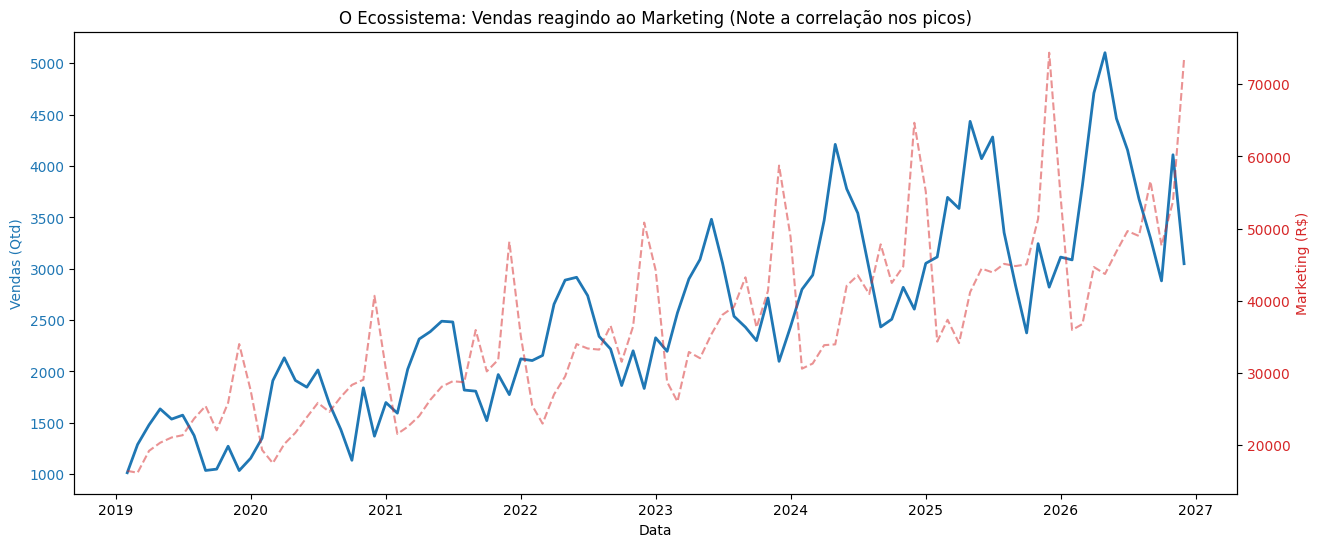

In [4]:
df_cenario = pd.DataFrame({
    'Data': datas_mensais,
    'Marketing': marketing,
    'Desconto': desconto,
    'Vendas_Total': vendas_totais
}).set_index('Data')

# Visualizar a correlação criada
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.set_xlabel('Data')
ax1.set_ylabel('Vendas (Qtd)', color='tab:blue')
ax1.plot(df_cenario.index, df_cenario['Vendas_Total'], color='tab:blue', linewidth=2, label='Vendas (Simuladas)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()  
ax2.set_ylabel('Marketing (R$)', color='tab:red')  
ax2.plot(df_cenario.index, df_cenario['Marketing'], color='tab:red', linestyle='--', alpha=0.5, label='Investimento Marketing')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('O Ecossistema: Vendas reagindo ao Marketing (Note a correlação nos picos)')
plt.show()

## 4. Granularização (ETL)
Transformamos os totais mensais calculados em transações diárias (linhas de pedidos), respeitando a distribuição histórica de Regiões e Categorias. Isso gera o arquivo final compatível com o Tableau/PowerBI e nossos modelos anteriores.

In [5]:
print("⚙️ Detalhando transações diárias (Paciência, processando 2019-2026)...")

novos_dados = []
regioes_pesos = df_raw['Region'].value_counts(normalize=True)
categorias = df_raw['Category'].unique()

for data_mensal, row in df_cenario.iterrows():
    total_qtd = int(row['Vendas_Total'])
    mkt_atual = row['Marketing']
    desc_atual = row['Desconto']
    
    # Quantidade de pedidos no mês
    num_pedidos = int(total_qtd / 3.5)
    
    fim_do_mes = data_mensal + pd.offsets.MonthEnd(0)
    dias = pd.date_range(start=data_mensal, end=fim_do_mes, freq='D')
    
    # Gerar pedidos
    # Otimização: Gerar arrays numpy de uma vez para velocidade
    datas_escolhidas = np.random.choice(dias, num_pedidos)
    regioes_escolhidas = np.random.choice(regioes_pesos.index, size=num_pedidos, p=regioes_pesos.values)
    categorias_escolhidas = np.random.choice(categorias, size=num_pedidos)
    qtds_escolhidas = np.random.randint(1, 7, size=num_pedidos)
    
    # Criar lista de dicionários
    for i in range(num_pedidos):
        novos_dados.append({
            'Order Date': datas_escolhidas[i],
            'Region': regioes_escolhidas[i],
            'Category': categorias_escolhidas[i],
            'Quantity': qtds_escolhidas[i],
            'Marketing_Invest': round(mkt_atual, 2), # Coluna Exógena 1
            'Discount_Rate': round(desc_atual, 3)    # Coluna Exógena 2
        })

df_final = pd.DataFrame(novos_dados).sort_values('Order Date')
arquivo_final = '../data/vendas_exogenas_2026.csv'
df_final.to_csv(arquivo_final, index=False)

print(f"\n✅ DATASET NOVO GERADO: {arquivo_final}")
print(f"📊 Colunas Extras: 'Marketing_Invest' e 'Discount_Rate'")
print(f"🔮 Vai até: {df_final['Order Date'].max().date()}")
print(df_final.head())

⚙️ Detalhando transações diárias (Paciência, processando 2019-2026)...

✅ DATASET NOVO GERADO: ../data/vendas_exogenas_2026.csv
📊 Colunas Extras: 'Marketing_Invest' e 'Discount_Rate'
🔮 Vai até: 2026-12-31
    Order Date   Region         Category  Quantity  Marketing_Invest  \
269 2019-02-01     West       Technology         1          16397.37   
27  2019-02-01     East  Office Supplies         1          16397.37   
67  2019-02-01  Central  Office Supplies         2          16397.37   
202 2019-02-01  Central  Office Supplies         1          16397.37   
233 2019-02-01     West       Technology         3          16397.37   

     Discount_Rate  
269           0.05  
27            0.05  
67            0.05  
202           0.05  
233           0.05  


## 5. Exportação
Salvando o arquivo na pasta `processed` para ser consumido pelo notebook de modelagem SARIMAX.

In [6]:
caminho_saida = '../data/processed/vendas_exogenas_2026.csv'
df_final.to_csv(caminho_saida, index=False)

print(f"💾 Arquivo salvo com sucesso: {caminho_saida}")

💾 Arquivo salvo com sucesso: ../data/processed/vendas_exogenas_2026.csv
